In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/clean.csv")
print(f"Dataset loaded: {df.shape[0]:,} records with {df.shape[1]} columns")
df.head()

Dataset loaded: 83,530 records with 19 columns


,category,location_type,context,outcome_status,persistent_id,id,location_subtype,month,latitude,location.street.id,street,longitude,outcome,outcome_status.date,fetched_month,date,year,month_n,season
0,anti-social-behaviour,Force,NaN,NaN,NaN,133811104,NaN,2026-02,53.364714,1712871,On or near Supermarket,-1.507240,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
1,anti-social-behaviour,Force,NaN,NaN,NaN,133806613,NaN,2026-02,53.357671,1718143,On or near Willbury Drive,-1.429404,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
2,anti-social-behaviour,Force,NaN,NaN,NaN,133803983,NaN,2026-02,53.418961,1717953,On or near Tenterden Road,-1.434182,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
3,anti-social-behaviour,Force,NaN,NaN,NaN,133813773,NaN,2026-02,53.366874,1717216,On or near Guildford Avenue,-1.446309,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
4,anti-social-behaviour,Force,NaN,NaN,NaN,133813771,NaN,2026-02,53.415489,1716883,On or near Horninglow Road,-1.454976,NaN,NaN,2026-02,2026-02-01,2026,2,Winter


In [3]:
coords = df[["latitude", "longitude"]].values
coords_rad = np.radians(coords)

print(f"Coordinates extracted: {coords.shape[0]:,} records with {coords.shape[1]} features")
print(f"lat range : {coords[:,0].min():.4f} - {coords[:,0].max():.4f}") 
print(f"lon range : {coords[:,1].min():.4f} - {coords[:,1].max():.4f}")

Coordinates extracted: 83,530 records with 2 features
lat range : 53.3201 - 53.4200
lon range : -1.5787 - -1.3501


In [ ]:
inertias = {}
silhouettes = {}

for k in range(2,12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_rad)
    inertias[k] = km.inertia_
    silhouettes[k] = silhouette_score(coords_rad, labels)
    print(f"K={k}: Inertia={inertias[k]:,.2f}, Silhouette={silhouettes[k]:.4f}")


K=2: Inertia=0.03, Silhouette=0.4834
K=3: Inertia=0.02, Silhouette=0.3588
K=4: Inertia=0.02, Silhouette=0.3609


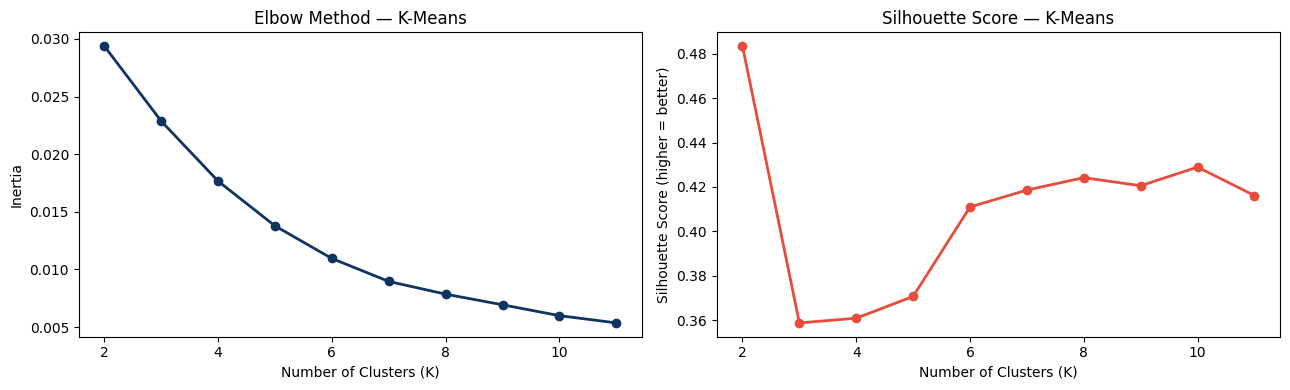


Best K by silhouette: 2  (score: 0.4834)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# elbow
ax1.plot(list(inertias.keys()), list(inertias.values()),
         marker="o", color="#0f3460", linewidth=2)
ax1.set_title("Elbow Method — K-Means")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")

# silhouette
ax2.plot(list(silhouettes.keys()), list(silhouettes.values()),
         marker="o", color="#e74c3c", linewidth=2)
ax2.set_title("Silhouette Score — K-Means")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score (higher = better)")

plt.tight_layout()
plt.savefig("../data/fig_kmeans_selection.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = max(silhouettes, key=silhouettes.get)
print(f"\nBest K by silhouette: {best_k}  (score: {silhouettes[best_k]:.4f})")


In [ ]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["kmeans_cluster"] = km_final.fit_predict(coords)

# evaluation
km_sil = silhouette_score(coords, df["kmeans_cluster"])
km_db  = davies_bouldin_score(coords, df["kmeans_cluster"])

print(f"K-Means — K={best_k}")
print(f"  Silhouette Score : {km_sil:.4f}  (closer to 1 = better)")
print(f"  Davies-Bouldin   : {km_db:.4f}   (closer to 0 = better)")
print(f"\nCluster sizes:")
print(df["kmeans_cluster"].value_counts().sort_index())


K-Means — K=2
  Silhouette Score : 0.4834  (closer to 1 = better)
  Davies-Bouldin   : 0.7976   (closer to 0 = better)

Cluster sizes:
kmeans_cluster
0    57464
1    26066
Name: count, dtype: int64


In [ ]:
import matplotlib.cm as cm

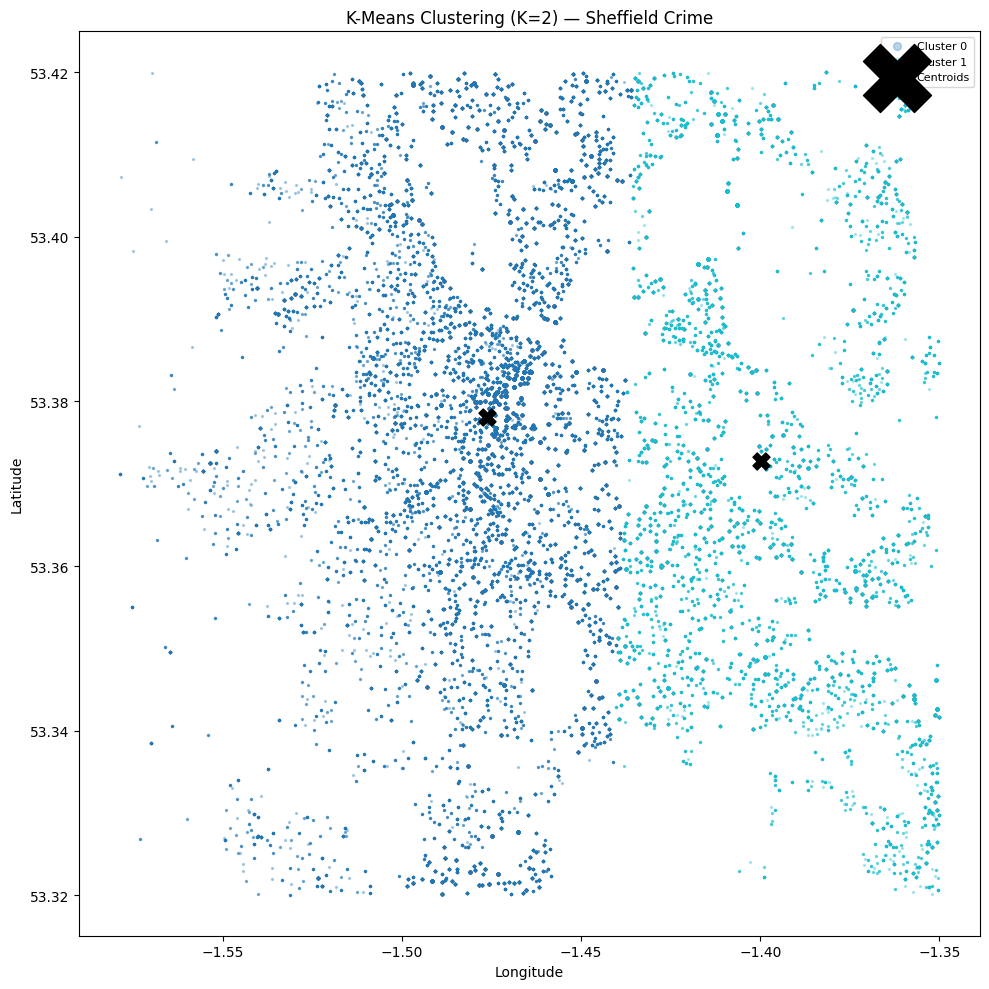

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
colors = cm.tab10(np.linspace(0, 1, best_k))

for cluster_id in range(best_k):
    mask = df["kmeans_cluster"] == cluster_id
    ax.scatter(
        df.loc[mask, "longitude"],
        df.loc[mask, "latitude"],
        s=2, alpha=0.3,
        color=colors[cluster_id],
        label=f"Cluster {cluster_id}"
    )

# plot centroids
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 1], centroids[:, 0],
           s=150, c="black", marker="X", zorder=5, label="Centroids")

ax.set_title(f"K-Means Clustering (K={best_k}) — Sheffield Crime")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=4, loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("../data/fig_kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# epsilon = distance in km converted to radians
# test a range of values to find the best one
epsilons   = [0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
min_samples = 20

print(f"{'Epsilon (km)':<15} {'Clusters':<12} {'Noise %':<12} {'Silhouette'}")
print("-" * 55)

results = []
for eps_km in epsilons:
    eps_rad = eps_km / 6371
    db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric="haversine")
    labels = db.fit_predict(coords_rad)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct  = (labels == -1).sum() / len(labels) * 100
    
    # only compute silhouette if we have at least 2 clusters
    mask = labels != -1
    sil = silhouette_score(coords[mask], labels[mask]) if n_clusters >= 2 and mask.sum() > 1 else 0
    
    print(f"{eps_km:<15} {n_clusters:<12} {noise_pct:<11.1f}% {sil:.4f}")
    results.append((eps_km, n_clusters, noise_pct, sil))


Epsilon (km)    Clusters     Noise %      Silhouette
-------------------------------------------------------
0.3             18           0.3        % -0.4915
0.4             6            0.1        % -0.3518
0.5             6            0.1        % -0.3517
0.6             2            0.1        % 0.4549
0.8             3            0.0        % 0.4545
1.0             1            0.0        % 0.0000


In [ ]:
BEST_EPS_KM = 0.5
MIN_SAMPLES = 20

eps_rad  = BEST_EPS_KM / 6371
db_final = DBSCAN(eps=eps_rad, min_samples=MIN_SAMPLES, metric="haversine")
df["dbscan_cluster"] = db_final.fit_predict(coords_rad)

n_clusters = len(set(df["dbscan_cluster"])) - (1 if -1 in df["dbscan_cluster"].values else 0)
noise_count = (df["dbscan_cluster"] == -1).sum()
noise_pct = noise_count / len(df) * 100

print(f"\nDBSCAN — Epsilon={BEST_EPS_KM} km, Min Samples={MIN_SAMPLES}")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {noise_count:,} ({noise_pct:.1f}%)")

mask = df["dbscan_cluster"] != -1
if n_clusters >= 2:
    db_sil = silhouette_score(coords[mask], df.loc[mask, "dbscan_cluster"])
    db_db = davies_bouldin_score(coords[mask] , df.loc[mask, "dbscan_cluster"])
    print(f"  Silhouette Score : {db_sil:.4f}  (closer to 1 = better)")
    print(f"  Davies-Bouldin   : {db_db:.4f}   (closer to 0 = better)")


DBSCAN — Epsilon=0.5 km, Min Samples=20
  Clusters found : 6
  Noise points   : 95 (0.1%)
  Silhouette Score : -0.3517  (closer to 1 = better)
  Davies-Bouldin   : 0.7603   (closer to 0 = better)


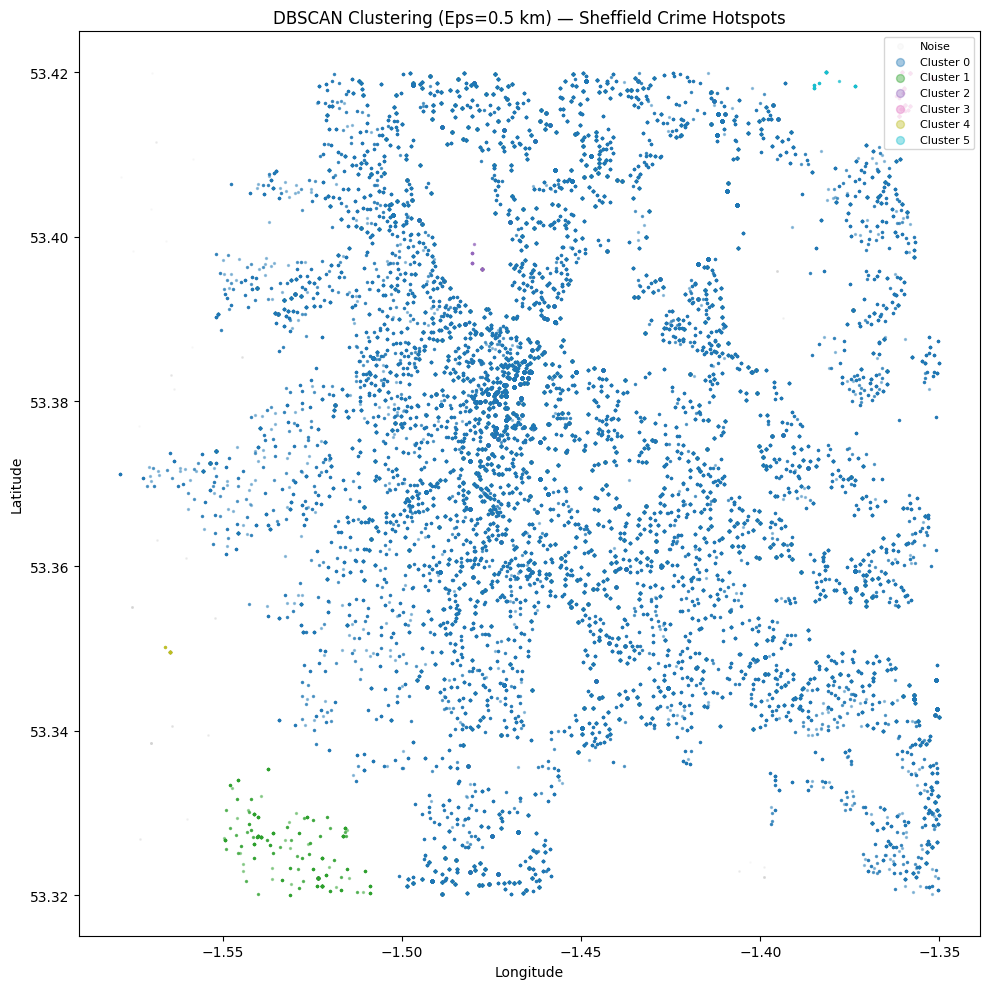

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

noise = df[df["dbscan_cluster"] == -1]
ax.scatter(noise["longitude"], noise["latitude"], s=1, alpha=0.1, color="lightgray", label="Noise")

unique_clusters = sorted(df[df["dbscan_cluster"] != -1]["dbscan_cluster"].unique())
colors = cm.tab10(np.linspace(0, 1, len(unique_clusters)))

for i, cid in enumerate(unique_clusters):
    mask = df["dbscan_cluster"] == cid
    ax.scatter(df.loc[mask, "longitude"], df.loc[mask, "latitude"],
               s=2, alpha=0.4, color=colors[i], label=f"Cluster {cid}")
    
ax.set_title(f"DBSCAN Clustering (Eps={BEST_EPS_KM} km) — Sheffield Crime Hotspots")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=4, loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("../data/fig_dbscan_clusters.png", dpi=150, bbox_inches="tight")
plt.show()